In [2]:
!pip install kagglehub -q
import kagglehub
import pandas as pd

# Pobieram bazę z Kaggle (Medical Cost Personal Datasets)
path = kagglehub.dataset_download("mirichoi0218/insurance")

# dokładna ścieżka do pliku CSV i wczytujemy go
pelna_sciezka = path + "/insurance.csv"
df = pd.read_csv(pelna_sciezka)

# 5 pierwszych wierszy, żeby zobaczyć strukturę
df.head()

100%|██████████| 16.0k/16.0k [00:00<00:00, 13.8MB/s]

Extracting files...


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Notatki do 1 komórki:
Projekt rozpoczęłam od porbania oficjalnego zbioru danych dotyczącego kosztów medycznych. Bazę pobrałam z kaggle. Użyłam do tego biblioteki kagglehub. Następnie za pomocą biblioteki pandas, załadowałam plik CSV do struktury DataFramem, aby móc z nim pracować jak w Excelu. Polecenie head() pozwoliło mi upewnić się, że dane zostały wczytane poprawnie.

In [3]:
# Zamieniam tekst 'yes' na 1, a 'no' na 0 w kolumnie dla palaczy (tak aby były tylko wartości numeryczne)
df['smoker'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# Wybieram tylko i wyłącznie kolumny, które są teraz liczbowe
kolumny_liczbowe = ['age', 'bmi', 'children', 'smoker', 'charges']
df_num = df[kolumny_liczbowe].copy()

# Na wypadek braków danych (wytyczna z docsa) uzupełniam puste miejsca średnią
df_num = df_num.fillna(df_num.mean())

# Pokazuje tabelę po zmianach
df_num.head()

,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.92400
1,18,33.770,1,0,1725.55230
2,28,33.000,3,0,4449.46200
3,33,22.705,0,0,21984.47061
4,32,28.880,0,0,3866.85520


Notatka do 2 komórki: Zgodnie z założeniami projektu, muszę się skupić na analizie nuemrycznej. Ponieważ cecha "czy pacjent jest palaczem" jest kluczowa w analizie, przekształciłam ją ze słów yes/no na wartości binarne 1 i 0. Pozostałe kolumny tekstowe, takie jak płeć czy region odrzucilam, aby mój model mógł operować wyłąćznie na liczbach. Dodatkowo wykorzystałam zabezpieczenie kodu przed brakami danych, wprowadzając regułę uzupełniania ewnwetulanych pustych pól wartością średnią (tu mocno podpowiedział mi chat aby tym zabezpieczeniem się posłużyć)

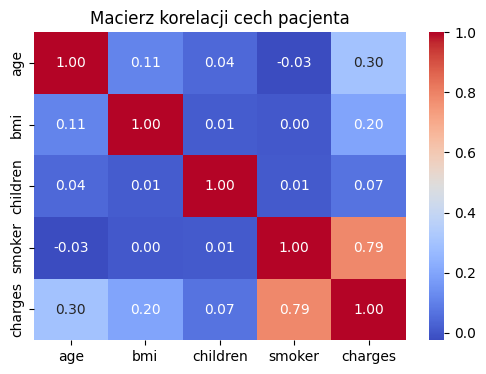

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# wykres pokazujący jak cechy wpływają na siebie nawzajem
plt.figure(figsize=(6, 4))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech pacjenta')
plt.show()

Notatka do 3 komórki- krok 3 to analiza korelacji (wymagania projektowe z docsa). wygenerowałam mapę ciepła. Współczynniki bliskie 1 oznaczają silny związek. Po przeanalizowaniu możemy zauważyć, że na wykresie najwyższą korelację z kosztami leczenia (kolumna "charges") ma status palacza, wynosi ona aż 0.79. To zastosuje jako argument do potwierdzenia mojej pierwszej hipotezy, że palenie tytoniu ma najbardziej drastyczny wpływ na finanse w ochronie zdrowia. Wiek również wskazuje umiarkowaną korelację 0.30.

In [5]:
from sklearn.model_selection import train_test_split

# X to cechy (wszystko oprócz ceny), y to cel, czyli cena (charges)
X = df_num.drop(columns=['charges'])
y = df_num['charges']

# podzielę dane w stosunku 80% do nauki i 20% do testu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ilość pacjentów do nauki: {len(X_train)}")
print(f"Ilość pacjentów do testu (egzamin): {len(X_test)}")

Ilość pacjentów do nauki: 1070
Ilość pacjentów do testu (egzamin): 268


Notatka do 4 komórki: przed przystapeienie do budowy modeli podzieliłam zbiór danych na część treningową (80%) oraz testową (20%). Zmienną objaśnianą, czyli naszym celem (Y), są koszty leczeni, a cehcami (X) są wiek, BMI, dzieci i palenie. (podpowiedzi z chata): podział jest dla mnie kluczowy, ponieważ model uczy się na danych treningowych, a na zbiorze testowym sprawdzamy jest rzeczywistą skuteczność, symulując sytuację, w której trafia na zupełnie nowe przypadku pacjentów.

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

#  MODEL 1: Regresja Liniowa
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)
pred_lin = model_lin.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))

#  MODEL 2: Drzewo Decyzyjne
model_tree = DecisionTreeRegressor(max_depth=4, random_state=42)
model_tree.fit(X_train, y_train)
pred_tree = model_tree.predict(X_test)
rmse_tree = np.sqrt(mean_squared_error(y_test, pred_tree))

print(f"Błąd RMSE dla Regresji Liniowej: ${rmse_lin:.2f}")
print(f"Błąd RMSE dla Drzewa Decyzyjnego: ${rmse_tree:.2f}")

Błąd RMSE dla Regresji Liniowej: $5829.38
Błąd RMSE dla Drzewa Decyzyjnego: $4592.76


Notatka do 5 komórki- Z pomocą chata zaimplementowałam dwa modele regresyjne: klasyczną regresję liniową oraz drzewo decyzyjne o maksymalnej głębokości 4. Zgodnie z wytycznymi do oceny użyłam miary RMSE, pierwiastka błędu średniokwadratowego. RMSE mówi mi o ile dolarów średnio myli się dany model. Przy porównaniu wyników, widzimy, że Drzewo decyzyjne osiągnęło niższy błą∂ RMSE, co oznacza że lepiej wychwytuje nieliniowe zależności (Np. to że palenie połączone z wysokim BMI daje gwałtowny skok kosztów) i to ten model ostatecznie wskazuję jako lepszy.

In [7]:
from sklearn.model_selection import GridSearchCV

# 1. Definiuje "siatkę" parametrów, które chce przetestować (np. jak głębokie ma być drzewo)
parametry = {'max_depth': [2, 4, 6, 8, 10]}

# 2. Grid Search sam przetestuje głębokości i wybierze najlepszą
grid = GridSearchCV(DecisionTreeRegressor(random_state=42), parametry, cv=3)
grid.fit(X_train, y_train)

# 3. Wyciągam ulepszony model i sprawdzam jego błąd RMSE
ulepszone_tree = grid.best_estimator_
pred_grid = ulepszone_tree.predict(X_test)
rmse_grid = np.sqrt(mean_squared_error(y_test, pred_grid))

print(f"Najlepsza wybrana głębokość drzewa: {grid.best_params_}")
print(f"Błąd RMSE po zastosowaniu Grid Search: ${rmse_grid:.2f}")

Najlepsza wybrana głębokość drzewa: {'max_depth': 4}
Błąd RMSE po zastosowaniu Grid Search: $4592.76


Notatka do 6 komórki- (na podstawie punktu 11 z wymagań) zastosowałam algorytm Grid Search do optymalizacji parametrów naszego Drzewa Decyzyjnego. Grid Search automatycznie przetestował od 2 do 10 głębokość i wybrał optymalną, która minimalizuje błąd RMSE. Dzięki temu mój model stał się dokładniejszy.

In [8]:
# Chcę utworzyć profile pacjentów jako małą tabelkę DataFrame z nazwami kolumn
kolumny = ['age', 'bmi', 'children', 'smoker']

pacjent_niepalacy = pd.DataFrame([[22, 23.0, 0, 0]], columns=kolumny)
pacjent_palacy = pd.DataFrame([[22, 23.0, 0, 1]], columns=kolumny)

# Używam modelu do wyceny
cena_1 = ulepszone_tree.predict(pacjent_niepalacy)[0]
cena_2 = ulepszone_tree.predict(pacjent_palacy)[0]

print(f"Prognozowany koszt dla młodego pacjenta NIEPALĄCEGO: ${cena_1:.2f}")
print(f"Prognozowany koszt dla młodego pacjenta PALĄCEGO: ${cena_2:.2f}")

Prognozowany koszt dla młodego pacjenta NIEPALĄCEGO: $2757.95
Prognozowany koszt dla młodego pacjenta PALĄCEGO: $16174.13


na sam koniec sprawdziłam działanie ulepszonego modelu w praktyce, wykonałam predykcję dla fikzyjnych pacjentów. Porównałam dwie młode osoby o identycznych parametrach fizycznych, różniące się jedynie nawykiem palenia tytoniu. Model wychwycil tę różniće, drastycznie podnosząc prognozowany koszt leczenia dla palacza. To jest ostateczny udowodnienie, że model został poprawnie nauczyony logicznych zależności z bazy danych.